In [1]:
from simsopt.mhd import Boozer,Vmec
from simsopt.geo import Surface,SurfaceRZFourier

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import time
import neo
from neo import NeoContext,neo_surfaces_from_simsopt_boozer
# def _parse_neo_out(path: Path) -> tuple[np.ndarray, np.ndarray]:
#     surfaces: list[int] = []
#     epstot: list[float] = []

#     for raw in path.read_text().splitlines():
#         line = raw.strip()
#         if not line:
#             continue
#         fields = line.split()
#         if len(fields) < 2:
#             continue
#         surfaces.append(int(fields[0]))
#         epstot.append(float(fields[1]))

#     return np.asarray(surfaces, dtype=np.int32), np.asarray(epstot, dtype=np.float64)



In [2]:
vmec_path = "/home/zkg/CN_H1_scan_fieldlines/H1_design/vmecpp/vmec_input/wout_h1_free_kh0.0_final_tf0.0450.nc"
sur_idx = np.linspace(0.1, 0.5, 10)

RZ_points = []  # 每个元素是 [R, phi, Z]
for s in sur_idx:
    surface = SurfaceRZFourier.from_wout(vmec_path, s)
    RphiZ = surface.cross_section(phi=0)[0]
    RZ = RphiZ[[0, 2]]   # shape: (Npts, 3)
    RZ_points.append(RZ)             # 第一个点: (3,)

RZ_points = np.asarray(RZ_points)       # shape: (len(sur_idx), 3) [R1,Z1], ...]

print(RZ_points)

[[1.20169176 0.        ]
 [1.19296033 0.        ]
 [1.18561402 0.        ]
 [1.1791666  0.        ]
 [1.17337019 0.        ]
 [1.16806255 0.        ]
 [1.16313826 0.        ]
 [1.15853409 0.        ]
 [1.15420104 0.        ]
 [1.15010856 0.        ]]


In [6]:
# Test importing the MGrid module
# %reset -f
import numpy as np
from mgrid import MGrid
# from ripple import initialize_mgrid_field,get_bfield_matrix

from effective_ripple import Effective_Ripple, effective_ripple
import time
from func_timeout import func_timeout, FunctionTimedOut
from scipy.optimize import root_scalar

def initialize_mgrid_field(mgrid_filename,nfp,full_torus=True):

    mgrid_raw = MGrid.from_file(mgrid_filename)
    mgrid_raw.expand_to_full_torus(nfp=nfp, full_torus=full_torus)
    nr, nz, nphi = mgrid_raw.nr, mgrid_raw.nz, mgrid_raw.nphi
    rmin, rmax = mgrid_raw.rmin, mgrid_raw.rmax
    zmin, zmax = mgrid_raw.zmin, mgrid_raw.zmax
    phimin = 0.0
    phimax = 2*np.pi/nfp if not full_torus else 2*np.pi
    print(f"✓ MGrid loaded successfully")
    print(f"  Grid dimensions: nr={nr}, nz={nz}, nphi={nphi}")
    print(f"  R range: [{rmin:.3f}, {rmax:.3f}]")
    print(f"  Z range: [{zmin:.3f}, {zmax:.3f}]")
    br_arr_db = mgrid_raw.br_arr
    bz_arr_db = mgrid_raw.bz_arr
    bp_arr_db = mgrid_raw.bp_arr
    nextcur = mgrid_raw.n_ext_cur

    Effective_Ripple.initialize_field(
        br_arr_db,bz_arr_db,bp_arr_db,
        rmin,rmax,nr,
        zmin,zmax,nz,
        phimin,phimax,nphi,
        nextcur
    )
    print("✓ Effective_Ripple field initialized.")
    return Effective_Ripple

def get_bfield_matrix(extcur, r, z, phi):
    """
    获取给定位置的磁场插值结果
    
    Parameters
    ----------
    extcur : array_like
        外部线圈电流组合
    r, z, phi : float or array_like
        插值位置坐标
        
    Returns
    -------
    b_matrix : ndarray, shape (12,) or (n, 12)
        磁场分量及其导数:
        [Br, Bz, Bphi, dBr/dr, dBr/dz, dBr/dphi, 
         dBz/dr, dBz/dz, dBz/dphi, dBphi/dr, dBphi/dz, dBphi/dphi]
    """
    if Effective_Ripple is None:
        raise ImportError("Effective_Ripple 未成功导入。")
    
    extcur = np.asarray(extcur, dtype=np.float64)
    Effective_Ripple.sum_bfield_internal(extcur)
    
    # 处理标量或数组输入
    if np.isscalar(r):
        # 单点插值
        result = Effective_Ripple.interpolate_field(float(r), float(z), float(phi))
        b_matrix = np.array(result, dtype=np.float64)
        # print("✓ Magnetic field interpolated at 1 point.")
    else:
        # 多点插值
        r_arr = np.atleast_1d(r).astype(np.float64)
        z_arr = np.atleast_1d(z).astype(np.float64)
        phi_arr = np.atleast_1d(phi).astype(np.float64)
        
        if not (len(r_arr) == len(z_arr) == len(phi_arr)):
            raise ValueError("r, z, phi 数组长度必须一致")
        
        npts = len(r_arr)
        results = np.zeros((npts, 12), dtype=np.float64)
        
        for i in range(npts):
            result_tuple = Effective_Ripple.interpolate_field(
                r_arr[i], z_arr[i], phi_arr[i]
            )
            results[i, :] = result_tuple
        
        b_matrix = results
        # print(f"✓ Magnetic field interpolated at {npts} points.")
    
    return b_matrix

def find_br_zero_point(extcur, R_target, z_search_range=(-0.2, 0.2)):
    """
    在固定 R 和 phi 下，搜索 Z 使得 Br(Z) ≈ 0
    返回最接近 Br=0 的点 (R, Z_found, phi)
    """
    def br_at_z(z):
        b_matrix = get_bfield_matrix(extcur, R_target, z, 0.0)
        return b_matrix[0]  # Br
    
    # 使用 root_scalar 在区间内找零点
    try:
        sol = root_scalar(br_at_z, bracket=z_search_range, xtol=1e-8)
        if sol.converged:
            Z_found = sol.root
            print(f"Found Br=0 at Z={Z_found:.6f}m, Br={br_at_z(Z_found):.2e}T.R_target = {R_target:.6f}m ")
            return R_target, Z_found
        else:
            raise ValueError("Root finding not converged")
    except ValueError:
        # fallback: 在范围内找 |Br| 最小的点
        z_test = np.linspace(z_search_range[0], z_search_range[1], 200)
        br_test = np.abs([br_at_z(z) for z in z_test])
        i_min = np.argmin(br_test)
        Z_found = z_test[i_min]
        print(f"Fallback: Min |Br|={br_test[i_min]:.2e}T at Z={Z_found:.6f}m")
        return R_target, Z_found

def compute_initial_gradpsi_Nemov(extcur,R0, Z0, phi0=0.0,verbose=True):
    """
    根据 Nemov 文章自动计算正确的初始 ∇ψ
    
    Parameters
    ----------
    R0, Z0, phi0 : float
        初始点坐标 (φ=0, z=0 轴上)
        
    Returns
    -------
    initial_gradpsi : ndarray, shape (3,)
        Nemov 变量: [P, G, Q] = [∂ψ/∂R, ∂ψ/∂Z, R*(∂ψ/∂φ)]
    info : dict
        包含计算详细信息的字典
    """
    
    # 1. 获取初始点的磁场和导数
    try:
        b_matrix = get_bfield_matrix(extcur, R0, Z0, phi0)
        
        # 解包磁场和导数
        Br0 = b_matrix[0]
        Bz0 = b_matrix[1]
        Bphi0 = b_matrix[2]
        
    except Exception as e:
        print(f"Error getting magnetic field: {e}")
        # 返回默认值（径向向外）
        return np.array([1.0, 0.0, 0.0]), {"error": str(e)}
    
    # 2. 计算磁场大小
    B_mag0 = np.sqrt(Br0**2 + Bz0**2 + Bphi0**2)
    
    # 3. 根据 Nemov 文章计算初始 ∇ψ 方向
    # 在 φ=0, z=0 点，磁面法向量 N = L × B
    # 其中 L = (0,0,1) (Z方向，磁面切向)
    # N = (0,0,1) × (Br, Bphi, Bz) = (-Bphi, Br, 0)
    N_R = -Bphi0
    N_phi = Br0     # 注意：这是角度分量 ∂ψ/∂φ 的方向，不是物理分量
    N_Z = 0.0
    
    # 4. 归一化法向量
    norm_N = np.sqrt(N_R**2 + N_phi**2 + N_Z**2)
    
    if norm_N < 1e-15:
        # 特殊情况：Bphi 和 Br 都为零
        print("Warning: Bphi and Br both zero at initial point. Using default direction.")
        n_R = 1.0
        n_phi = 0.0
        n_Z = 0.0
    else:
        n_R = N_R / norm_N
        n_phi = N_phi / norm_N
        n_Z = N_Z / norm_N
    
    # 5. 转换为 ∇ψ 的物理分量
    # ∇ψ 物理分量 = (∂ψ/∂R, (1/R)∂ψ/∂φ, ∂ψ/∂Z)
    grad_psi_R_phys = n_R                     # ∂ψ/∂R
    grad_psi_phi_phys = n_phi                 # (1/R)∂ψ/∂φ
    grad_psi_Z_phys = n_Z                     # ∂ψ/∂Z
    
    # 6. 转换为 Nemov 变量 P, G, Q
    P0 = grad_psi_R_phys                      # ∂ψ/∂R
    G0 = grad_psi_Z_phys                      # ∂ψ/∂Z
    
    # ∂ψ/∂φ = R * (1/R)∂ψ/∂φ = R * grad_psi_phi_phys
    # Q = R * (∂ψ/∂φ) = R² * grad_psi_phi_phys
    Q0 = R0**2 * grad_psi_phi_phys
    
    # 7. 计算 |∇ψ| 验证归一化
    # |∇ψ| = sqrt(P² + (Q/R²)² + G²) = sqrt(n_R² + n_phi² + n_Z²)
    grad_psi_mag = np.sqrt(P0**2 + (Q0/(R0**2))**2 + G0**2)
    
    # 8. 验证 B·∇ψ = 0
    B_dot_grad = Br0 * P0 + Bphi0 * grad_psi_phi_phys + Bz0 * G0
    
    
    # 10. 打印信息
    if verbose:
        print("="*60)
        print("AUTO-COMPUTED INITIAL ∇ψ")
        print("="*60)
        print(f"Initial point: R={R0:.6f}, Z={Z0:.6f}, φ={phi0:.6f}")
        print(f"Magnetic field: Br={Br0:.6f}, Bφ={Bphi0:.6f}, Bz={Bz0:.6f}")
        print(f"Magnetic field magnitude: {B_mag0:.6f}")
        print(f"Normal vector (N = L×B): [{N_R:.6f}, {N_phi:.6f}, {N_Z:.6f}]")
        print(f"Unit normal: [{n_R:.6f}, {n_phi:.6f}, {n_Z:.6f}]")
        print(f"∇ψ physical components: [{grad_psi_R_phys:.6f}, {grad_psi_phi_phys:.6f}, {grad_psi_Z_phys:.6f}]")
        print(f"Nemov variables: P={P0:.6f}, G={G0:.6f}, Q={Q0:.6f}")
        print(f"|∇ψ| = {grad_psi_mag:.6f} (should be 1.0)")
        print(f"B·∇ψ = {B_dot_grad:.2e} (should be ~0)")
        print("="*60)
    
    return np.array([P0, G0, Q0])

def compute_initial_gradpsi_Nemov_lasym(extcur, R0, Z0, phi0=0.0, verbose=True):
    """
    Nemov et al. (2010) 方法计算无 stellarator symmetry 配置下的初始 ∇ψ
    返回 Nemov 变量 [P, G, Q] = [∂ψ/∂R, ∂ψ/∂Z, R ∂ψ/∂φ]
    """
    # 1. 初始化磁场和追踪参数
    nturn = 200
    nphi = 360
    if not sum_bfield_internal:
        Effective_Ripple.sum_bfield_internal(extcur)
    Effective_Ripple.set_trace_parameters(nturn, nphi)  # 100 poloidal × 360 toroidal 步数，可根据需要增大
    initial_rzphi = np.array([R0, Z0], dtype=np.float64)
    b_matrix = get_bfield_matrix(extcur, R0, Z0, phi0)
    B_vec=np.array([b_matrix[0], b_matrix[1], b_matrix[2]], dtype=np.float64)
    B_mag = np.linalg.norm(B_vec)
    e_rho = np.array([1.0, 0.0, 0.0])
    e_z   = np.array([0.0, 1.0, 0.0])
    # ∇Q1_st=B×e_z=[-Bz, 0, Br], ∇Q2_st=B×e_R=[0, Bphi, -Bz]
    gradpsi_z_st = np.cross(B_vec, e_z) / B_mag    # ∇θ₁ = B × e_z / B
    gradpsi_z_st[2] *= R0  # 转换为 R ∂ψ/∂φ
    gradpsi_z_st /= np.linalg.norm(gradpsi_z_st)
    gradpsi_r_st = np.cross(B_vec, e_rho) / B_mag  # ∇θ₂ = B × e_ρ / B
    gradpsi_r_st[2] *= R0  # 转换为 R ∂ψ/∂φ
    gradpsi_r_st /= np.linalg.norm(gradpsi_r_st)
    print(f"Initial gradpsi_r_st: {gradpsi_r_st}, gradpsi_z_st: {gradpsi_z_st}")

    # 2. 追踪径向初始向量 ∇Q1_st = [1,0,0]
    fieldline_data_r = np.zeros((nturn*nphi, 20), dtype=np.float64, order='F')
    Effective_Ripple.trace_gradpsi_internal(fieldline_data_r, initial_rzphi, gradpsi_r_st)

    # 3. 追踪轴向初始向量 ∇Q2_st = [0,0,1]
    fieldline_data_z = np.zeros((nturn*nphi, 20), dtype=np.float64, order='F')
    Effective_Ripple.trace_gradpsi_internal(fieldline_data_z, initial_rzphi, gradpsi_z_st)

    # 4. 提取轨迹数据（列定义见你的注释）
    #    列 1:R, 2:Z, 3:phi, 8:dpsi/dR, 9:dpsi/dZ, 10:R dpsi/dphi
    R_trace   = fieldline_data_r[:, 0]
    Z_trace   = fieldline_data_r[:, 1]
    phi_trace = fieldline_data_r[:, 2]
    gradpsi_r   = fieldline_data_r[:, 7:10]   # [∂ψ/∂R, ∂ψ/∂Z, R∂ψ/∂φ] 沿轨迹
    gradpsi_z   = fieldline_data_z[:, 7:10]

    R = np.reshape(R_trace, (nturn, nphi))
    Z = np.reshape(Z_trace, (nturn, nphi))
    phi = np.reshape(phi_trace, (nturn, nphi))
    # check matrix shape by phi
    R0_matrix = R[:,0]
    Z0_matrix = Z[:,0]
    phi0_matrix = phi[1:,0]
    
    # print(f"Phi0 matrix check: mean={np.mean(abs(phi0_matrix)):.6f}  min={np.min(phi0_matrix):.6f}, max={np.max(phi0_matrix):.6f}")


    dist_r=np.sqrt((R0_matrix - R0)**2 + (Z0_matrix - Z0)**2)
    dist_z=np.sqrt((R0_matrix - R0)**2 + (Z0_matrix - Z0)**2)
    dist_s= np.sqrt(dist_r**2+dist_z**2)
    idx_fin = np.argmin(dist_s[1:]) + 1  # 排除起始点

    gradpsi1_fin = gradpsi_r[idx_fin, :]  # 径向追踪终点 ∇Q1_fin
    gradpsi2_fin = gradpsi_z[idx_fin, :]  # 轴向追踪终点 ∇Q2_fin

    # 6. 计算 ΔQ1, ΔQ2
    gradpsi1_st = gradpsi_r_st  # [1,0,0]
    gradpsi2_st = gradpsi_z_st  # [0,0,1]

    delta_Q1 = gradpsi1_fin - gradpsi1_st
    delta_Q2 = gradpsi2_fin - gradpsi2_st

    # 7. 计算 λ = -b / a
    a = np.dot(delta_Q2, delta_Q2)
    b = np.dot(delta_Q1, delta_Q2)

    if abs(a) < 1e-20:
        if verbose:
            print("Warning: a ≈ 0, ΔQ2 几乎为零，使用默认径向方向")
        lambda_coeff = 0.0
    else:
        lambda_coeff = -b / a

    # 8. 真正的初始 ∇ψ（Nemov 变量 [P, G, Q]）
    initial_gradpsi = gradpsi1_st + lambda_coeff * gradpsi2_st  # [∂ψ/∂R, ∂ψ/∂Z, R ∂ψ/∂φ]

    # 9. 可选：归一化 |∇ψ|（如果后续需要单位法向）
    # grad_psi_phys = [initial_gradpsi[0], initial_gradpsi[2]/R0, initial_gradpsi[1]]
    # mag = np.sqrt(np.sum(np.array(grad_psi_phys)**2))
    # if mag > 1e-12:
    #     initial_gradpsi /= mag
    #     initial_gradpsi[2] *= R0   # 恢复 Q = R ∂ψ/∂φ

    # 10. 验证与输出
    if verbose:
        print("="*60)
        print("Nemov (2010) 无对称性初始 ∇ ψ 计算结果")
        print("="*60)
        print(f"初始点: R={R0:.6f}, Z={Z0:.6f}, φ={phi0:.6f}")
        print(f"返回点距离: {min(dist_r[idx_fin], dist_z[idx_fin]):.2e}")
        print(f"λ 系数: {lambda_coeff:.10f}")
        print(f"初始 ∇ ψ (Nemov变量): P={initial_gradpsi[0]:.10f}, G={initial_gradpsi[1]:.10f}, Q={initial_gradpsi[2]:.10f}")
        # 计算 |∇ψ| 和 B·∇ψ 验证
        B_at_st = np.array([fieldline_data_r[0,3], fieldline_data_r[0,5], fieldline_data_r[0,4]])  # Br, Bp, Bz
        grad_phys = np.array([initial_gradpsi[0], initial_gradpsi[2]/R0, initial_gradpsi[1]])
        B_dot_grad = np.dot(B_at_st, grad_phys)
        mag_grad = np.linalg.norm(grad_phys)
        print(f"|∇ ψ| (物理) = {mag_grad:.10f}")
        print(f"B · ∇ ψ = {B_dot_grad:.2e} (应接近 0)")
        print("="*60)
    P0 = initial_gradpsi[0]
    G0 = initial_gradpsi[1]
    Q0 = initial_gradpsi[2]

    return np.array([P0, G0, Q0])

def calculate_plasma_params(fieldline_data, axis_data, nturn, nphi, Rm, nfp):
    """
    针对 R, Z, Phi 数据的体积及 Iota 计算
    :param fieldline_data: (nphi*nturn, 3) -> [R, Z, Phi]
    :param axis_data: (nphi+1, 3) -> [R, Z, Phi] 磁轴轨迹
    :param nturn: 极向采样点数
    :param nphi: 环向采样点数
    :param Rm: 大半径
    :param nfp: 场周期数
    :return: (volume, a_minor, iota)
    """
    
    # 1. 数据重塑 (按照 R, Z, Phi 分离)
    # 假设 fieldline_data 是按 [nturn, nphi] 排列的场线点
    R = fieldline_data[:, 0].reshape((nturn, nphi)).T # (nphi, nturn)
    Z = fieldline_data[:, 1].reshape((nturn, nphi)).T # (nphi, nturn)
    Phi = fieldline_data[:, 2].reshape((nturn, nphi)).T # (nphi, nturn)

    # 2. 获取磁轴参考点
    # 取对应环向位置的磁轴坐标。假设 axis_data 长度与 nphi 匹配
    # 如果 axis_data 是 (nphi+1, 3)，取前 nphi 个点
    R_axis = axis_data[:nphi, 0].reshape(-1, 1) # 变成列向量以便广播
    Z_axis = axis_data[:nphi, 1].reshape(-1, 1)

    # 3. 极向排序与体积计算
    # 计算极向角进行排序
    thetas = np.arctan2(Z - Z_axis, R - R_axis)
    
    # 预准备排序后的数组
    R_sorted = np.zeros_like(R)
    Z_sorted = np.zeros_like(Z)
    
    for i in range(nphi):
        idx = np.argsort(thetas[i, :])
        R_sorted[i, :] = R[i, idx]
        Z_sorted[i, :] = Z[i, idx]

    # 利用滚位计算截面积分 (Green公式)
    R_next = np.roll(R_sorted, -1, axis=1)
    Z_next = np.roll(Z_sorted, -1, axis=1)
    # 体积元累加
    vol_sum = np.sum((R_next - R_sorted) * (R_next + R_sorted) * (Z_next + Z_sorted))
    volume = abs(vol_sum) * (np.pi / nphi)
    
    # 有效小半径
    am = np.sqrt(volume / (2 * np.pi**2 * Rm))

    # 4. 计算 Iota (Rotational Transform)
    # 注意：计算 iota 通常需要追踪场线在极向角上的连续变化
    # 我们计算第一条场线（或平均）在环向一周内的极向角跨度
    
    # 取第一条追踪场线的坐标轨迹 (假设 fieldline_data 的排列允许提取连续轨迹)
    # 如果 data 是由平衡代码生成的磁面点，iota 通常是输入参数或通过磁通量导出的。
    # 这里提供一种基于坐标演化的几何估计方法：
    
    # 计算相对于磁轴的极向角演化（不排序，使用原始轨迹顺序）
    # 假设 R[0, :] 是一条场线在不同环向角下的 R 坐标
    # 但根据你的 nphi/nturn 结构，通常 R[:, 0] 是固定极向位置在环向的分布
    
    # 几何法估算：iota \approx d_theta / d_phi
    # 提取一条连续场线轨迹（这里假设 fieldline_data 的原始顺序即场线追踪顺序）
    # 如果数据只是磁面上的点阵而非轨迹，请注意该 iota 仅为几何近似
    d_theta = np.unwrap(thetas[:, 0]) # 展开相位，避免 +-pi 跳变
    d_phi = np.unwrap(Phi[:, 0])     # 环向角展开
    
    # 拟合斜率即为 iota
    if len(d_phi) > 1:
        iota = (d_theta[-1] - d_theta[0]) / (d_phi[-1] - d_phi[0])
    else:
        iota = 0.0

    return volume, am, abs(iota)

def find_axis(initial_rz, xtol=1e-10, max_iter=200, timeout=10.0):
    """
    Find the magnetic axis by ensuring the fieldline returns to the start after one toroidal turn.
    
    Parameters
    ----------
    initial_guess : array_like
        Initial (R, Z) guess for the magnetic axis
    xtol : float, optional
        Tolerance for convergence
    max_iter : int, optional
        Maximum number of iterations
    timeout : float, optional
        Maximum time in seconds before raising timeout error (default: 10.0)
        
    Returns
    -------
    tuple
        (axis_position, major_radius, fieldline_data, trace_error_flag)
        - axis_position: ndarray [R, Z] of magnetic axis (nan if timeout)
        - major_radius: float, R0 (nan if timeout)
        - fieldline_data: ndarray, traced fieldline data (nan if timeout)
        - trace_error_flag: bool, True if timeout or error occurred
    """
    from scipy.optimize import root
    import signal
    
    class TimeoutError(Exception):
        pass
    
    def timeout_handler(signum, frame):
        raise TimeoutError("Magnetic axis search timeout")
    
    print(f"\nSearching for magnetic axis...")
    print(f"  Initial guess: R={initial_rz[0]:.6f}, Z={initial_rz[1]:.6f}")
    print(f"  Timeout: {timeout:.1f} s")

    Effective_Ripple.set_trace_parameters(2, 360)
    initial_gradpsi = [0,0,0]
    initial_gradpsi = np.array(initial_gradpsi, dtype=np.float64, order='F')

    # 存储最后一次成功的 fieldline_data
    final_fieldline_data = None
    trace_error_flag = False

    def axis_residual(initial_rz):
        nonlocal final_fieldline_data
        initial_rz = np.array(initial_rz, dtype=np.float64, order='F')
        fieldline_data = np.zeros((2*360, 20), dtype=np.float64, order='F')
        try:
            Effective_Ripple.trace_gradpsi_internal(fieldline_data, initial_rz, initial_gradpsi)
            final_R = fieldline_data[360, 0]
            final_Z = fieldline_data[360, 1]
            residual = np.array([final_R - initial_rz[0], final_Z - initial_rz[1]])
            # 保存成功追踪的数据
            final_fieldline_data = fieldline_data.copy()
            return residual
        except Exception as e:
            print(f"  Warning: Fieldline tracing failed at R={initial_rz[0]:.6f}, Z={initial_rz[1]:.6f}: {e}")
            return np.array([1e10, 1e10])

    try:
        # 设置超时信号 (仅在 Unix-like 系统上可用)
        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(int(timeout))
        
        # 单核单线程优化求解 (hybr 方法本身是单线程的)
        result = root(
            axis_residual,
            initial_rz,
            method='hybr',  # 单线程 Powell hybrid 方法
            tol=xtol,
            options={
                'maxfev': max_iter * (len(initial_rz) + 1),
                'factor': 100  # 初始步长因子,可调
            }
        )
        
        # 取消超时
        signal.alarm(0)
        
        final_residual = result.fun
        distance = np.linalg.norm(final_residual)
        
        # 计算主半径 R0
        if final_fieldline_data is not None:
            R0 = np.mean(np.sqrt(final_fieldline_data[:360, 0]**2 + final_fieldline_data[:360, 1]**2))
        else:
            R0 = np.nan
            trace_error_flag = True
        
        print("  Optimization completed:")
        print(f"    Axis position: R={result.x[0]:.10f}, Z={result.x[1]:.10f}")
        print(f"    Major radius R0: {R0:.10f}")
        print(f"    Distance error: {distance:.2e}")
        print(f"    Converged: {result.success}")
        
        return result.x, R0, final_fieldline_data, trace_error_flag
    
    except TimeoutError:
        signal.alarm(0)  # 取消信号
        print(f"  ✗ Timeout: Magnetic axis search exceeded {timeout:.1f} s")
        trace_error_flag = True
        return np.array([np.nan, np.nan]), np.nan, None, trace_error_flag
    
    except Exception as e:
        signal.alarm(0)  # 取消信号
        print(f"  ✗ Error during axis search: {e}")
        trace_error_flag = True
        return np.array([np.nan, np.nan]), np.nan, None, trace_error_flag

def compute_effective_ripple(extcur,initial_rz,R0):
    Effective_Ripple.sum_bfield_internal(extcur)
    Effective_Ripple.trace_gradpsi_internal(fieldline_data, initial_rz, initial_gradpsi)
    Bboundary = Effective_Ripple.geodesic_curvature_internal(fieldline_data,geocur)
    epsilon_eff = R0*R0*Effective_Ripple.effective_ripple_internal(fieldline_data,geocur)

    return epsilon_eff,Bboundary

def save_hdf5_fieldline(filename, fieldline_data,epsilon_eff,Bboundary):
    import h5py
    with h5py.File(filename, 'w') as f:
        f.create_dataset('fieldline_data', data=fieldline_data)
        f.create_dataset('epsilon_eff', data=epsilon_eff)
        f.create_dataset('Bboundary', data=Bboundary)
    print(f"✓ Fieldline data saved to {filename}")

def find_axis_with_timeout(initial_rz, timeout=10.0, xtol=1e-10, max_iter=200):
    """
    包装 find_axis 函数,设置超时限制
    
    Parameters
    ----------
    initial_rz : tuple
        初始 (R, Z) 猜测值
    timeout : float, optional
        超时时间(秒),默认 10.0
    xtol : float, optional
        收敛容差
    max_iter : int, optional
        最大迭代次数
        
    Returns
    -------
    tuple
        (axis_position, major_radius, fieldline_data, trace_error_flag)
        超时时返回 (nan, nan, None, True)
    """
    
    def _find_axis_worker():
        """内部工作函数,不带超时逻辑"""
        from scipy.optimize import root
        
        print(f"\nSearching for magnetic axis...")
        print(f"  Initial guess: R={initial_rz[0]:.6f}, Z={initial_rz[1]:.6f}")
        print(f"  Timeout: {timeout:.1f} s")

        Effective_Ripple.set_trace_parameters(2, 360)
        # Effective_Ripple.sum_bfield_internal(extcur)
        initial_gradpsi = [0,0,0]
        initial_gradpsi = np.array(initial_gradpsi, dtype=np.float64, order='F')

        final_fieldline_data = None

        def axis_residual(initial_rz):
            nonlocal final_fieldline_data
            initial_rz = np.array(initial_rz, dtype=np.float64, order='F')
            fieldline_data = np.zeros((2*360, 20), dtype=np.float64, order='F')
            try:
                Effective_Ripple.trace_gradpsi_internal(fieldline_data, initial_rz, initial_gradpsi)
                final_R = fieldline_data[360, 0]
                final_Z = fieldline_data[360, 1]
                residual = np.array([final_R - initial_rz[0], final_Z - initial_rz[1]])
                final_fieldline_data = fieldline_data.copy()
                return residual
            except Exception as e:
                print(f"  Warning: Fieldline tracing failed: {e}")
                return np.array([1e10, 1e10])

        # 单线程优化求解
        result = root(
            axis_residual,
            initial_rz,
            method='hybr',
            tol=xtol,
            options={
                'maxfev': max_iter * (len(initial_rz) + 1),
                'factor': 100
            }
        )
        
        # 计算主半径 R0
        if final_fieldline_data is not None:
            R0 = np.mean(np.sqrt(final_fieldline_data[:360, 0]**2 + final_fieldline_data[:360, 1]**2))
        else:
            R0 = np.nan
            raise RuntimeError("No valid fieldline data")
        
        distance = np.linalg.norm(result.fun)
        
        print("  Optimization completed:")
        print(f"    Axis position: R={result.x[0]:.10f}, Z={result.x[1]:.10f}")
        print(f"    Major radius R0: {R0:.10f}")
        print(f"    Distance error: {distance:.2e}")
        print(f"    Converged: {result.success}")
        
        return result.x, R0, final_fieldline_data, False

    # 使用 func_timeout 包装
    try:
        result = func_timeout(timeout, _find_axis_worker)
        return result
    
    except FunctionTimedOut:
        print(f"  ✗ Timeout: Magnetic axis search exceeded {timeout:.1f} s", flush=True)
        return np.array([np.nan, np.nan]), np.nan, None, True
    
    except Exception as e:
        print(f"  ✗ Error during axis search: {e}", flush=True)
        return np.array([np.nan, np.nan]), np.nan, None, True

def compute_initial_gradpsi_Nemov_lasym_relaxed_closure(
    extcur, 
    R0, Z0, 
    phi0=0.0, 
    nturn=500,          # 建议 300~1000，根据破对称程度增大
    nphi=360,           # 每圈 toroidal 步数
    dist_tol=1e-3,      # 返回点距离阈值（NEO-2 常用 1e-3~1e-4）
    min_points=5,       # 最少需要多少个合格返回点
    verbose=True
):
    """
    Nemov et al. (2010) + NEO-2 改进版：无 stellarator symmetry 配置下计算初始 ∇ψ
    关键改进：
      - Relaxed closure：不再强求单一点精确返回，而是取最后若干近返回点做最小二乘
      - 多点平均 λ（更稳定，尤其在 CNH1 破对称下）
      - 完整 B·∇ψ 和 |∇ψ| 验证 + 自动 fallback
    返回 Nemov 变量 [P, G, Q] = [∂ψ/∂R, ∂ψ/∂Z, R ∂ψ/∂φ]
    """
    import numpy as np

    # ====================== 1. 初始化 ======================
    if not sum_bfield_internal:
        Effective_Ripple.sum_bfield_internal(extcur)
    Effective_Ripple.set_trace_parameters(nturn, nphi)

    initial_rzphi = np.array([R0, Z0], dtype=np.float64)
    b_matrix = get_bfield_matrix(extcur, R0, Z0, phi0)
    B_vec = np.array([b_matrix[0], b_matrix[1], b_matrix[2]], dtype=np.float64)
    B_mag = np.linalg.norm(B_vec)

    # 初始梯度（柱坐标物理基矢）
    e_rho = np.array([1.0, 0.0, 0.0])
    e_z   = np.array([0.0, 1.0, 0.0])

    gradQ1_st = np.cross(B_vec, e_z) / B_mag          # ∇Q1_st ≈ e_z 方向
    gradQ1_st[2] *= R0                                # 转为 Q = R ∂ψ/∂φ
    gradQ1_st /= np.linalg.norm(gradQ1_st)

    gradQ2_st = np.cross(B_vec, e_rho) / B_mag        # ∇Q2_st ≈ e_ρ 方向
    gradQ2_st[2] *= R0
    gradQ2_st /= np.linalg.norm(gradQ2_st)

    if verbose:
        print(f"Initial gradQ1_st (z-dir): {gradQ1_st}")
        print(f"Initial gradQ2_st (ρ-dir): {gradQ2_st}")

    # ====================== 2. 场线追踪（两个初始向量） ======================
    fieldline_data_Q1 = np.zeros((nturn * nphi, 20), dtype=np.float64, order='F')
    Effective_Ripple.trace_gradpsi_internal(fieldline_data_Q1, initial_rzphi, gradQ1_st)

    fieldline_data_Q2 = np.zeros((nturn * nphi, 20), dtype=np.float64, order='F')
    Effective_Ripple.trace_gradpsi_internal(fieldline_data_Q2, initial_rzphi, gradQ2_st)

    # 提取轨迹
    R_trace   = fieldline_data_Q1[:, 0]
    Z_trace   = fieldline_data_Q1[:, 1]
    phi_trace = fieldline_data_Q1[:, 2]
    gradQ1    = fieldline_data_Q1[:, 7:10]   # [P, G, Q] 沿轨迹
    gradQ2    = fieldline_data_Q2[:, 7:10]

    # ====================== 3. 寻找所有“近返回点”（relaxed closure） ======================
    # 只看 φ ≈ 0 平面（排除起点）
    phi_mod = np.mod(phi_trace, 2 * np.pi)
    mask = (phi_mod < 0.05) & (np.arange(len(phi_trace)) > nphi)   # 至少走过一圈

    dist = np.sqrt((R_trace[mask] - R0)**2 + (Z_trace[mask] - Z0)**2)

    # 筛选合格返回点
    good_idx = np.where(dist < dist_tol)[0]
    if len(good_idx) < min_points:
        if verbose:
            print(f"Warning: 只找到 {len(good_idx)} 个合格返回点 (dist < {dist_tol})，"
                  f"尝试放宽阈值或增加 nturn")
        # 放宽一次
        good_idx = np.where(dist < 5 * dist_tol)[0]
        if len(good_idx) == 0:
            if verbose:
                print("Error: 完全无法找到返回点！使用默认径向方向")
            return np.array([1.0, 0.0, 0.0])   # fallback

    # 取最后若干个点（越靠后越接近闭合）
    good_idx = good_idx[-min(20, len(good_idx)):]   # 最多取最后20个

    # ====================== 4. 最小二乘求 λ ======================
    delta_Q1_list = gradQ1[mask][good_idx] - gradQ1_st
    delta_Q2_list = gradQ2[mask][good_idx] - gradQ2_st

    # 构造最小二乘系统：min || ΔQ1 + λ ΔQ2 ||²
    A = np.stack(delta_Q2_list)          # shape (N, 3)
    b = -np.stack(delta_Q1_list)         # shape (N, 3)
    # λ = (A^T A)^(-1) (A^T b)   → 标量
    lambda_coeff = np.linalg.lstsq(A, b, rcond=None)[0].mean()   # 平均三个分量结果

    if verbose:
        print(f"找到 {len(good_idx)} 个返回点，平均距离 = {dist[good_idx].mean():.2e}")
        print(f"λ = {lambda_coeff:.10f}")

    # ====================== 5. 计算初始 ∇ψ ======================
    initial_gradpsi = gradQ1_st + lambda_coeff * gradQ2_st   # [P, G, Q]

    # ====================== 6. 验证与归一化 ======================
    # B · ∇ψ
    B0 = np.array([fieldline_data_Q1[0, 3], fieldline_data_Q1[0, 5], fieldline_data_Q1[0, 4]])  # Br, Bφ, Bz
    grad_phys = np.array([initial_gradpsi[0], initial_gradpsi[2] / R0, initial_gradpsi[1]])
    B_dot_grad = np.dot(B0, grad_phys)

    # |∇ψ|
    mag = np.linalg.norm(grad_phys)
    if mag > 1e-12:
        initial_gradpsi /= mag          # 归一化到 |∇ψ| = 1
        initial_gradpsi[2] *= R0        # 恢复 Q = R ∂ψ/∂φ

    if verbose:
        print("=" * 70)
        print("Nemov + NEO-2 改进版初始 ∇ψ 计算完成")
        print("=" * 70)
        print(f"初始点          : R={R0:.6f}, Z={Z0:.6f}, φ={phi0:.6f}")
        print(f"合格返回点数量   : {len(good_idx)} (dist_tol={dist_tol})")
        print(f"λ 系数           : {lambda_coeff:.10f}")
        print(f"初始 ∇ψ (Nemov)  : P={initial_gradpsi[0]:.10f}, G={initial_gradpsi[1]:.10f}, Q={initial_gradpsi[2]:.10f}")
        print(f"|∇ψ| (物理)      : {mag:.10f}  → 已归一化")
        print(f"B · ∇ψ           : {B_dot_grad:.2e}  (理想 ≈ 0)")
        if abs(B_dot_grad) > 1e-6:
            print("   Warning: B·∇ψ 偏离零，可能需增大 nturn 或调整 dist_tol")
        print("=" * 70)

    return np.array([initial_gradpsi[0], initial_gradpsi[1], initial_gradpsi[2]], dtype=np.float64)

# compute_initial_gradpsi = compute_initial_gradpsi_Nemov_lasym
compute_initial_gradpsi = compute_initial_gradpsi_Nemov
# compute_initial_gradpsi = compute_initial_gradpsi_Nemov_lasym_relaxed_closure
# compute_initial_gradpsi = compute_initial_gradpsi_SVD
# compute_initial_gradpsi = compute_initial_gradpsi_Jacobian


full_torus = False
# nfp = 1
# mgrid_filename = '/home/zkg/CN_H1_scan_fieldlines/CN_H1/coils/mgrid_h1_measure.nc'
nfp = 3
mgrid_filename = '/home/zkg/CN_H1_scan_fieldlines/H1_design/coils/mgrid_h1_design.nc'
extcur = [50000, 5000, 1, -80000, -40000]
nturn = 100
nphi = 360
initialize_mgrid_field(mgrid_filename, nfp,full_torus=full_torus)


Effective_Ripple.sum_bfield_internal(extcur)
sum_bfield_internal = True
initial_rz = (1.26,0)
starttime = time.time()
axis_rz,R0, axis_fieldline, trace_error_flag = find_axis_with_timeout(initial_rz, timeout=10.0, xtol=1e-5, max_iter=100)
endtime = time.time()
time_elapsed = endtime - starttime
print(f"✓ Magnetic axis found at R={axis_rz[0]:.10f}, Z={axis_rz[1]:.10f}, R0={R0:.10f}, time={time_elapsed:.3f} s")
starttime = time.time()
epsilon_eff_arr = []
Bboundary_arr = []
initial_gradpsi = [1,0,0]
Effective_Ripple.set_trace_parameters(nturn, nphi)
for i in range(RZ_points.shape[0]):
    initial_rz = RZ_points[i]
    fieldline_data = np.zeros((effective_ripple.npoints, 20), dtype=np.float64, order='F')
    geocur = np.zeros((nturn*nphi, 3), dtype=np.float64, order='F')
    R0 = np.array(R0, dtype=np.float64, order='F')
    Bboundary = np.array(0.0, dtype=np.float64, order='F')
    initial_rz = np.array(initial_rz, dtype=np.float64, order='F') 
    epsilon_eff, Bboundary = compute_effective_ripple(extcur, initial_rz, R0)
    epsilon_eff_arr.append(epsilon_eff)
    Bboundary_arr.append(Bboundary)
endtime = time.time()
time_elapsed = endtime - starttime
print(f"✓ Ripple fieldline computed. epsilon_eff={epsilon_eff:.6e}, Bboundary={Bboundary:.6e},time={time_elapsed:.3f} s")

starttime = time.time()
vol, a_minor, iota = calculate_plasma_params(fieldline_data, axis_fieldline[:nphi+1,:3], nturn, nphi, R0, nfp)
endtime = time.time()
time_elapsed = endtime - starttime
print(f"✓ Physics parameters calculated in {time_elapsed:.3f} s")
print(f"✓ Physics parameters calculated: Volume={vol:.6f}, a_minor={a_minor:.6f}, Iota={iota:.6f}")

✓ MGrid loaded successfully
  Grid dimensions: nr=141, nz=131, nphi=37
  R range: [0.300, 1.700]
  Z range: [-0.650, 0.650]
✓ Effective_Ripple field initialized.
Field initialization completed for 5 coil groups.

Searching for magnetic axis...
  Initial guess: R=1.260000, Z=0.000000
  Timeout: 10.0 s
Trace parameters set: nturn=2, nphi=360, npoints=720
  Optimization completed:
    Axis position: R=1.2476513393, Z=-0.0000000448
    Major radius R0: 1.0222043183
    Distance error: 5.40e-09
    Converged: True
✓ Magnetic axis found at R=1.2476513393, Z=-0.0000000448, R0=1.0222043183, time=0.158 s
Trace parameters set: nturn=100, nphi=360, npoints=36000
✓ Ripple fieldline computed. epsilon_eff=6.028401e-01, Bboundary=3.953730e-01,time=41.293 s
✓ Physics parameters calculated in 0.034 s
✓ Physics parameters calculated: Volume=0.910263, a_minor=0.212398, Iota=1.118203


In [4]:
vmec = Vmec(str(vmec_path))
boozer = Boozer(vmec)
boozer.mpol = 36
boozer.ntor = 72
# ns_list =  np.array([2, 3, 4, 5, 6, 7, 8, 9, 10])
# boozer.register(ns_list/100)
boozer.register(sur_idx)
boozer.bx.verbose =True
boozer.run()
neoclass = neo.from_simsopt_boozer(boozer)
# neoclass = neo.from_boozmn_netcdf("/Users/dmcxe/Downloads/pyNEO/tests/boozmn_ncsx_c09r00_free.nc")
ctx = NeoContext()
ctx.set_boozer(neoclass)
# ctx.set_flux_surfaces([2, 3, 4, 5, 6, 7, 8, 9, 10])
surfaces = neo_surfaces_from_simsopt_boozer(boozer)
print('Surfaces from simsopt Boozer:', surfaces)
ctx.set_flux_surfaces(surfaces.tolist())
ctx.set_resolution(theta_n=200, phi_n=200)
ctx.set_mode_limits(max_m_mode=0, max_n_mode=0)
ctx.set_transport_options(
    npart=50,
    multra=1,
    acc_req=0.01,
    no_bins=100,
    nstep_per=50,
    nstep_min=500,
    nstep_max=5000,
    calc_nstep_max=0,
)
ctx.set_switches(ref_swi=2, eout_swi=2, calc_cur=0)
ctx.set_output_options(
    write_progress=0,
    write_output_files=0,
    write_integrate=0,
    write_diagnostic=0,
    suppress_file_io=True,
)

ctx.setup_grids()
ctx.run_all()
got_surfaces = ctx.surface_map()
got_epstot = ctx.epstot_profile()

Read ns=99, mpol=8, ntor=14, mnmax=218, mnmax_nyq=426
compute_surfs (0-based indices):  9 14 18 22 27 31 35 40 44 48
Initializing with mboz=36, nboz=72
ntheta = 146, nzeta = 290, # threads = 12
                   |        outboard (theta=0)      |      inboard (theta=pi)      |
thread js_b js zeta| |B|input  |B|Boozer    Error   | |B|input  |B|Boozer    Error |
------------------------------------------------------------------------------------
   4     4  27   0  3.752e-01  3.752e-01  8.754e-11  2.807e-01  2.807e-01  5.151e-09
                pi  4.598e-01  4.598e-01  7.547e-09  5.168e-01  5.168e-01  1.773e-09
   3     3  22   0  3.686e-01  3.686e-01  9.661e-10  2.839e-01  2.839e-01  3.965e-09
                pi  4.605e-01  4.605e-01  3.440e-09  5.110e-01  5.110e-01  1.731e-09
   1     1  14   0  3.571e-01  3.571e-01  5.809e-10  2.902e-01  2.902e-01  8.469e-10
                pi  4.624e-01  4.624e-01  2.626e-10  5.014e-01  5.014e-01  3.500e-10
   5     5  31   0  3.803e-01  3.803e-01 

pyneo: [0.37941653 0.39671186 0.41175692 0.42922135 0.44991975 0.46577568
 0.48257752 0.50611515 0.52827512 0.54968239]
ripplepy: [0.23775547045252032, 0.3591586725884345, 0.27910943974010144, 0.4107176113191118, 0.3376897001681897, 0.4789730808714392, 0.28610075322374895, 0.5456005488734331, 0.5124736226636226, 0.6028400558053639]


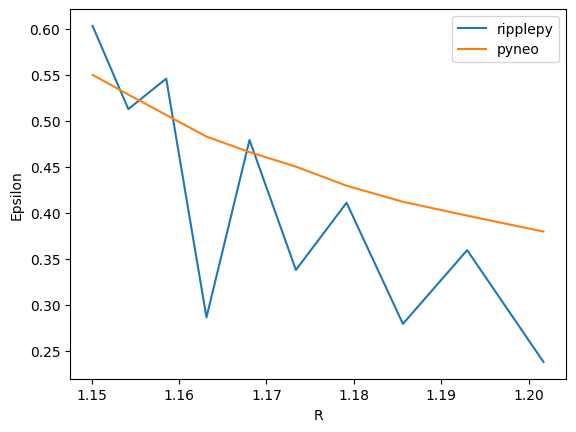

In [7]:
# ref_epstot = epsilon_eff_arr *2 
ref_epstot = [epsilon_eff_arr [i] * 1 for i in range(len(epsilon_eff_arr))]
ref_surfaces = RZ_points[:,0]  # 假设 RZ_points 的第一列是表面索引或半径

print('pyneo:', got_epstot)
print('ripplepy:', ref_epstot)

plt.figure()
plt.plot(ref_surfaces, ref_epstot, label="ripplepy")
plt.plot(ref_surfaces, got_epstot, label="pyneo")
plt.xlabel("R")
plt.ylabel("Epsilon")
plt.legend()
plt.show()